# Point Cloud Registration

Implements the paper's Section 2.4.4 in full - registration *and* the confidence-weighted merge
it also describes - following on from [cropping.ipynb](cropping.ipynb). Each of the three sets
was captured with the object resting differently on the turntable (a different face presented to
the always-overhead camera), so each of Step 6's three cropped point-clouds is a genuine partial
view in its own independent frame; this step brings them into one.

> Point-cloud registration is performed in two stages:
> - Automatic coarse alignment of point-clouds using the Super 4PCS algorithm,
> - Fine alignment using a Weighted Iterative Closest Point (W-ICP) algorithm.

and, on merging the aligned clouds:

> c(pi) = 1/2 (nz + 1)(1 &minus; e^(&minus;z/&lambda;)) ... ri = (c(pi)Akpi + c(qj)qj) / (c(pi) + c(qj))

**Pipeline in this notebook** (see `utils/registration.py`'s module docstring for the two
substitutions this replica needed and why):
1. Load each set's cropped point-cloud and Step 6's own crop metadata (the z lower-limit each
   set's confidence values are measured relative to).
2. Estimate per-point surface normals (PCA over local neighbours - Step 5's dense reconstruction
   doesn't preserve the photo-consistency normals PatchMatchStereo computed) and, from them plus
   each point's height above its own crop base, the paper's confidence metric.
3. Pick one set as the reference frame and, for each remaining set: **coarse-align** it onto the
   (growing) merged cloud with no initial guess (a RANSAC congruent-triple search, substituting
   for Super4PCS), then **refine** with Weighted ICP.
4. **Merge**: confidence-weighted-interpolate close/overlapping point pairs into one (the paper's
   Equation 4); keep the rest as-is. This also prunes the redundant duplicate points registration
   creates in overlap regions - there's no separate pruning stage in this replica's pipeline.
5. Write the merged point-cloud and every set's rigid transform (needed again in Step 9,
   Texturing, to reposition each partial model's own cameras) to `outputs/merged/`.

In [1]:
from pathlib import Path
import json
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial import cKDTree

from utils import registration as reg

## Parameters

In [2]:
SET_NAMES = ["set_1", "set_2", "set_3"]
REFERENCE_SET = "set_1"  # arbitrary choice of reference frame - the others are registered onto it

ROOT = Path.cwd()
OUT_DIR = ROOT / "outputs" / "merged"
OUT_PLY = OUT_DIR / "merged.ply"
OUT_TRANSFORMS = OUT_DIR / "transforms.json"
OUT_CONFIDENCE = OUT_DIR / "merged_confidence.npy"  # Step 8 (meshing) needs this for Poisson point-weighting

# Confidence metric (paper Eq. 2).
NORMAL_K = 16       # neighbours used for PCA normal estimation
LAMBDA_MM = 1.0      # paper: "a value of approximately 1mm has been found to work well in practice"

# Coarse alignment (RANSAC congruent-triple search, substituting for Super4PCS - see
# utils/registration.py's module docstring).
COARSE_N_SEARCH_POINTS = 500
COARSE_N_TRIALS = 500
COARSE_MAX_TOTAL_CANDIDATES = 6000
COARSE_DISTANCE_TOLERANCE_MM = 1.0
COARSE_OVERLAP_THRESHOLD_MM = 1.5
COARSE_MIN_BASE_SPREAD_MM = 8.0
COARSE_N_SCORE_POINTS = 1500

# Fine alignment (Weighted ICP).
ICP_MAX_ITERATIONS = 60
ICP_MAX_CORRESPONDENCE_DISTANCE_MM = 4.0

# Merge (paper Eq. 4): points from two clouds closer than this are treated as redundant
# observations of the same surface and interpolated into one.
MERGE_RADIUS_MM = 1.0

if OUT_DIR.exists():
    import shutil
    shutil.rmtree(OUT_DIR)
OUT_DIR.mkdir(parents=True)

## Step 1 - Load each set's cropped point-cloud, normals, and confidence

Confidence is computed once per set, in that set's own original (pre-registration) frame - it
reflects the acquisition geometry (lighting/viewing angle, height above that capture's own
turntable), which doesn't change no matter how the cloud later gets rotated to register it.

In [3]:
sets = {}
for name in SET_NAMES:
    points, colors = reg.read_ply(ROOT / "outputs" / name / "cropped" / "cropped.ply")
    meta = json.loads((ROOT / "outputs" / name / "cropped" / "crop_metadata.json").read_text())

    normals = reg.estimate_normals(points, k=NORMAL_K)
    confidence = reg.compute_confidence(points, normals, meta["z_lower_limit_mm"], lam=LAMBDA_MM)

    sets[name] = dict(points=points, colors=colors, normals=normals, confidence=confidence, meta=meta)
    print(f"{name}: {len(points):,} points, confidence mean={confidence.mean():.2f} "
          f"(min={confidence.min():.2f}, max={confidence.max():.2f})")

set_1: 44,317 points, confidence mean=0.63 (min=0.00, max=1.00)


set_2: 51,330 points, confidence mean=0.58 (min=0.00, max=1.00)


set_3: 47,524 points, confidence mean=0.59 (min=0.00, max=1.00)


## Step 2 - Confidence maps

Colour each set by its own confidence value (dark = unreliable, bright = reliable) - the same
diagnostic the paper's own Figure 8 shows for a single point-cloud, here for all three.

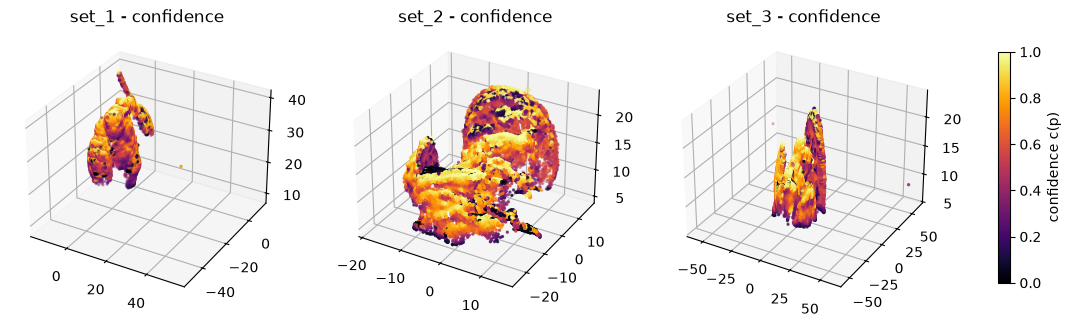

In [4]:
fig = plt.figure(figsize=(15, 5))
for i, name in enumerate(SET_NAMES):
    s = sets[name]
    ax = fig.add_subplot(1, 3, i + 1, projection="3d")
    sample = np.random.default_rng(0).choice(len(s["points"]), size=min(20_000, len(s["points"])), replace=False)
    sc = ax.scatter(s["points"][sample, 0], s["points"][sample, 1], s["points"][sample, 2],
                     c=s["confidence"][sample], cmap="inferno", vmin=0, vmax=1, s=2)
    ax.set_title(f"{name} - confidence")
plt.colorbar(sc, ax=fig.axes, shrink=0.6, label="confidence c(p)")
plt.show()

## Step 3 - Register each set onto the growing merged cloud

`REFERENCE_SET` seeds the merged cloud as-is; each remaining set is coarse-aligned (no initial
guess) and then refined with Weighted ICP against whatever has been merged so far, then folded in
via the confidence-weighted merge. Registering against the *growing* merged cloud (rather than
only ever against the original reference) gives later sets more surface to match against.

In [5]:
merged_points = sets[REFERENCE_SET]["points"].copy()
merged_colors = sets[REFERENCE_SET]["colors"].copy()
merged_confidence = sets[REFERENCE_SET]["confidence"].copy()

transforms = {REFERENCE_SET: {"R": np.eye(3).tolist(), "t": [0.0, 0.0, 0.0]}}
registration_log = []

remaining = [n for n in SET_NAMES if n != REFERENCE_SET]
for name in remaining:
    src = sets[name]
    t0 = time.time()

    coarse = reg.coarse_align(
        src["points"], merged_points,
        n_search_points=COARSE_N_SEARCH_POINTS, n_trials=COARSE_N_TRIALS,
        max_total_candidates=COARSE_MAX_TOTAL_CANDIDATES,
        distance_tolerance=COARSE_DISTANCE_TOLERANCE_MM, overlap_threshold=COARSE_OVERLAP_THRESHOLD_MM,
        min_base_spread=COARSE_MIN_BASE_SPREAD_MM, n_score_points=COARSE_N_SCORE_POINTS,
    )
    t_coarse = time.time()

    R, t, icp_history = reg.weighted_icp(
        src["points"], src["confidence"], merged_points, merged_confidence,
        init_R=coarse.R, init_t=coarse.t,
        max_iterations=ICP_MAX_ITERATIONS, max_correspondence_distance=ICP_MAX_CORRESPONDENCE_DISTANCE_MM,
    )
    t_icp = time.time()

    transformed_points = reg.apply_transform(src["points"], R, t)
    tree = cKDTree(merged_points)
    nn_dist, _ = tree.query(transformed_points, k=1, workers=-1)

    print(f"{name}: coarse score={coarse.score:.3f} ({coarse.num_candidates_evaluated} candidates, "
          f"{t_coarse-t0:.1f}s) -> ICP {len(icp_history)} iters ({t_icp-t_coarse:.1f}s) "
          f"-> median nn dist {np.median(nn_dist):.2f}mm, {np.mean(nn_dist < COARSE_OVERLAP_THRESHOLD_MM):.1%} "
          f"within {COARSE_OVERLAP_THRESHOLD_MM}mm of the merged cloud so far")

    transforms[name] = {"R": R.tolist(), "t": t.tolist()}
    registration_log.append(dict(name=name, coarse_score=coarse.score, icp_iterations=len(icp_history),
                                  median_nn_dist_mm=float(np.median(nn_dist))))

    before_n = len(merged_points)
    merged_points, merged_colors, merged_confidence = reg.merge_point_clouds(
        merged_points, merged_colors, merged_confidence,
        transformed_points, src["colors"], src["confidence"],
        merge_radius=MERGE_RADIUS_MM,
    )
    print(f"  merged {before_n:,} + {len(src['points']):,} -> {len(merged_points):,} points")

set_2: coarse score=0.558 (6000 candidates, 53.3s) -> ICP 60 iters (1.5s) -> median nn dist 0.40mm, 68.6% within 1.5mm of the merged cloud so far
  merged 44,317 + 51,330 -> 62,113 points


set_3: coarse score=0.915 (6000 candidates, 44.0s) -> ICP 60 iters (1.3s) -> median nn dist 0.26mm, 91.3% within 1.5mm of the merged cloud so far
  merged 62,113 + 47,524 -> 67,820 points


## Before / after: each set in its own frame vs. the final merged cloud

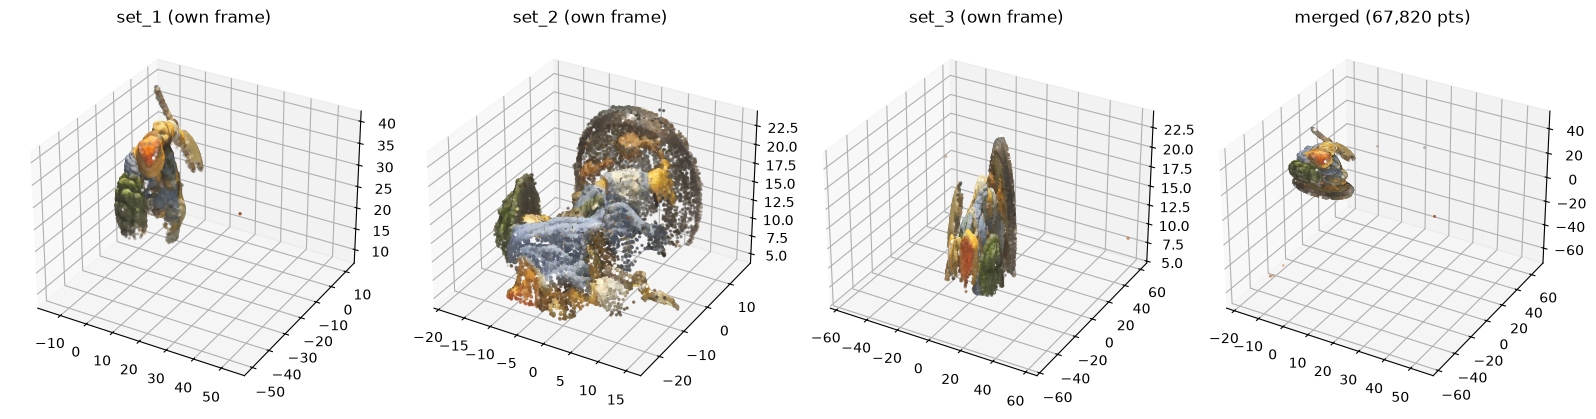

In [6]:
fig = plt.figure(figsize=(16, 4))
for i, name in enumerate(SET_NAMES):
    s = sets[name]
    ax = fig.add_subplot(1, 4, i + 1, projection="3d")
    sample = np.random.default_rng(0).choice(len(s["points"]), size=min(20_000, len(s["points"])), replace=False)
    ax.scatter(s["points"][sample, 0], s["points"][sample, 1], s["points"][sample, 2],
               c=s["colors"][sample] / 255.0, s=2)
    ax.set_title(f"{name} (own frame)")

ax = fig.add_subplot(1, 4, 4, projection="3d")
sample = np.random.default_rng(0).choice(len(merged_points), size=min(60_000, len(merged_points)), replace=False)
ax.scatter(merged_points[sample, 0], merged_points[sample, 1], merged_points[sample, 2],
           c=merged_colors[sample] / 255.0, s=1)
ax.set_title(f"merged ({len(merged_points):,} pts)")
plt.tight_layout()
plt.show()

## Write the merged point-cloud and per-set transforms

In [7]:
reg.write_ply(OUT_PLY, merged_points, merged_colors)
print(f"wrote {OUT_PLY}")

np.save(OUT_CONFIDENCE, merged_confidence)
print(f"wrote {OUT_CONFIDENCE}")

OUT_TRANSFORMS.write_text(json.dumps(transforms, indent=2))
print(f"wrote {OUT_TRANSFORMS}")

wrote /mnt/c/Users/gnoceras/Documents/GustavoPersonal/ScanningTable/outputs/merged/merged.ply
wrote /mnt/c/Users/gnoceras/Documents/GustavoPersonal/ScanningTable/outputs/merged/merged_confidence.npy
wrote /mnt/c/Users/gnoceras/Documents/GustavoPersonal/ScanningTable/outputs/merged/transforms.json


## Summary

In [8]:
print("registration:")
for entry in registration_log:
    print(f"  {entry['name']}: coarse score={entry['coarse_score']:.3f}, "
          f"{entry['icp_iterations']} ICP iterations, median nn dist={entry['median_nn_dist_mm']:.2f}mm")
print()
print(f"reference set:      {REFERENCE_SET}")
print(f"input point counts: " + ", ".join(f"{n}={len(sets[n]['points']):,}" for n in SET_NAMES))
print(f"merged point count:  {len(merged_points):,}")
print(f"wrote:               {OUT_PLY}")
print(f"                     {OUT_TRANSFORMS}")

registration:
  set_2: coarse score=0.558, 60 ICP iterations, median nn dist=0.40mm
  set_3: coarse score=0.915, 60 ICP iterations, median nn dist=0.26mm

reference set:      set_1
input point counts: set_1=44,317, set_2=51,330, set_3=47,524
merged point count:  67,820
wrote:               /mnt/c/Users/gnoceras/Documents/GustavoPersonal/ScanningTable/outputs/merged/merged.ply
                     /mnt/c/Users/gnoceras/Documents/GustavoPersonal/ScanningTable/outputs/merged/transforms.json
